# Support Vector Machines (SVM) with PCA Preprocessing on the MNIST Dataset

## Notebook Goal
This notebook implements a **Support Vector Machine (SVM)** classifier with a non-linear kernel (**RBF**) for handwritten digit recognition. To get strong performance with a reasonable runtime, we apply the findings from our earlier study by using **Principal Component Analysis (PCA)** to keep 95% of the variance before training.

## Why combine PCA (95%) and SVM?
- **Raw MNIST:** Has 784 dimensions (28x28 pixels). An SVM on such a large space suffers from the "Curse of Dimensionality" and runtimes explode.
- **Reduction to 95% variance:** As shown in the Denoising (Noising) notebook, around 154 principal components are enough to capture all the useful geometric structure of the digits while removing background noise.
- **Synergy:** PCA drastically speeds up SVM training and improves its robustness against overfitting.

## Project Flow
1. Import the libraries and set up the local cache (Docker).
2. Load the persistent MNIST dataset.
3. Normalize the data.
4. Apply PCA to compress the space down to 95% of the informative variance.
5. Train the SVM (RBF kernel) on a controlled subset.
6. Fully evaluate performance (accuracy, confusion matrix, metric report).

In [1]:
# ============================================================================
# 1. IMPORTING THE ESSENTIAL LIBRARIES
# ============================================================================

# Core libraries for data handling and plotting
import numpy as np               # For matrix computations and array handling
import pandas as pd              # For tabular data analysis
import matplotlib.pyplot as plt  # For plotting and confusion matrices
from pathlib import Path         # For clean, robust file path handling
import warnings                  # For managing runtime warnings

# scikit-learn tools for loading, splitting, and scaling
from sklearn.datasets import fetch_openml        # To load MNIST from OpenML or the cache
from sklearn.model_selection import train_test_split # To split the data into Train/Test
from sklearn.preprocessing import StandardScaler  # To standardize the features (mean=0, variance=1)
from sklearn.decomposition import PCA            # For linear dimensionality reduction

# SVM model and performance metrics
from sklearn.svm import SVC                      # The Support Vector Classification model
from sklearn.metrics import accuracy_score       # To measure the overall correct-classification rate
from sklearn.metrics import confusion_matrix     # To see the details of inter-class errors
from sklearn.metrics import classification_report # To compute Precision, Recall, and F1-Score

# Turn off warnings to keep the notebook clean
warnings.filterwarnings('ignore')

# Set the plot style for consistent visuals
plt.style.use('seaborn-v0_8-darkgrid')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# ============================================================================
# 2. PATH SETUP - PROJECT ORGANIZATION
# ============================================================================
# Same local structure as the previous notebooks, to keep data persistent:
#   ./data/         ← Root folder for the container's persistent data
#   ./data/cache/   ← OpenML cache layer read by scikit-learn
# ============================================================================

# Automatically find the project root based on where the notebook runs from
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

# Define the subfolders for storing data cleanly
DATA_DIR = PROJECT_ROOT / 'data'
CACHE_DIR = DATA_DIR / 'cache'
DATASETS_DIR = DATA_DIR / 'datasets'
MNIST_CACHE_DIR = CACHE_DIR / 'openml'

# Automatically create the folders if they don't exist yet on Docker
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATASETS_DIR.mkdir(parents=True, exist_ok=True)
MNIST_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Paths and Docker folder structure initialized!')

✅ Paths and Docker folder structure initialized!


## STEP 2: Load MNIST from the Local Cache
To avoid downloading the 70,000 images every time the Docker container restarts, we check the `CACHE_DIR` folder. If scikit-learn finds the MNIST signature there, loading is instant.

In [3]:
# ============================================================================
# 3. SAFELY LOADING MNIST FROM THE DOCKER CACHE
# ============================================================================

print('📥 Checking for and loading MNIST from the local OpenML cache...')

# Scan the cache folder to see if the MNIST binary file is already there
cache_hits = list(MNIST_CACHE_DIR.glob('**/*mnist*'))
if cache_hits:
    print(f'   -> Cache files found: {len(cache_hits)}. Loading locally right away.')
else:
    print('   -> No cache found. Downloading for the first time (will save automatically)...')

# Call OpenML pointed at our persistent storage folder
X_full, y_full = fetch_openml(
    'mnist_784',          # Exact name of the official MNIST dataset
    version=1,            # Reference version
    return_X_y=True,      # Return a separate (images, labels) tuple
    as_frame=False,       # Force Numpy array format (faster than Pandas)
    parser='auto',        # Internal scikit-learn parsing optimization
    data_home=str(CACHE_DIR), # Force storage in our persistent folder
)

# Explicitly convert labels from strings ('0') to integers (0)
y_full = y_full.astype(int)

print('✅ Full MNIST dataset retrieved successfully!')
print(f'📊 Raw dimensions: {X_full.shape[0]} images of {X_full.shape[1]} pixels.')

📥 Checking for and loading MNIST from the local OpenML cache...
   -> No cache found. Downloading for the first time (will save automatically)...
✅ Full MNIST dataset retrieved successfully!
📊 Raw dimensions: 70000 images of 784 pixels.


## STEP 3: Stratification, Scaling, and Dimensionality Reduction (PCA)
Since SVM has quadratic algorithmic complexity relative to the number of samples ($O(N^2)$), training it on all 70,000 images would take a very long time without a GPU.

We follow a rigorous approach:
1. Set aside a representative subset of **20,000 images** for training (statistically very solid for MNIST) and **5,000 images** for testing.
2. Use a **stratified** split (`stratify=y`) to keep exactly the same proportions for each digit (0 to 9).
3. **Standardize** the data (center and scale).
4. Apply our **95%-variance PCA** to go from 784 variables to around 154 optimal components.

In [4]:
# ============================================================================
# 4. STRATIFIED SPLIT AND PCA COMPRESSION (95% VARIANCE)
# ============================================================================

# Build a clean subset of 20,000 images for training and 5,000 for testing
# stratify=y_full ensures the model sees the same proportion of '3's as '8's, etc.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, 
    train_size=20000,     # Training set size
    test_size=5000,       # Validation/test set size
    stratify=y_full,      # Keep class balance
    random_state=42       # Seed for reproducibility
)

print('⚡ Step 1: Standardizing pixel intensities...')
# Instantiate the scaler to normalize the pixel distribution
scaler = StandardScaler()
# Compute the parameters (mean and standard deviation) on the training set only, then apply
X_train_scaled = scaler.fit_transform(X_train_raw)
# Apply the same transform to the test set to avoid data leakage
X_test_scaled = scaler.transform(X_test_raw)

print('🌀 Step 2: Applying PCA with 95% explained variance...')
# Configure PCA to automatically find the number of components needed for 95% of the signal
pca_95 = PCA(n_components=0.95, random_state=42)

# Fit PCA on the scaled training set and project onto the new axes
X_train_pca = pca_95.fit_transform(X_train_scaled)
# Simply project the test set into the new compressed space
X_test_pca = pca_95.transform(X_test_scaled)

# Get the magic number of components computed by PCA
n_features_retained = X_train_pca.shape[1]

print('\n✅ Preprocessing complete!')
print(f'   -> Original space: {X_train_raw.shape[1]} dimensions.')
print(f'   -> New space compressed by PCA: {n_features_retained} dimensions.')
print(f'   -> Compression rate: computation reduced by {((1 - n_features_retained/784)*100):.1f}%!')

⚡ Step 1: Standardizing pixel intensities...
🌀 Step 2: Applying PCA with 95% explained variance...

✅ Preprocessing complete!
   -> Original space: 784 dimensions.
   -> New space compressed by PCA: 308 dimensions.
   -> Compression rate: computation reduced by 60.7%!


## STEP 4: Training the Non-Linear SVM (RBF Kernel)
Since the 3D projections from our earlier notebooks showed that digit classes overlap in a non-linear way, we use an **RBF (Radial Basis Function) kernel**.

This kernel implicitly projects our data into an infinite-dimensional space (Hilbert space) through the *Kernel Trick*, to find the optimal separating hyperplane with the widest possible margin.

In [5]:
# ============================================================================
# 5. SETTING UP AND TRAINING THE SVM (RBF KERNEL)
# ============================================================================

print('🤖 Initializing the SVM model with a Gaussian (RBF) kernel...')
# Create the SVC classifier instance
#   kernel='rbf' : Allows non-linear, curved separation
#   C=5.0        : Regularization parameter (tradeoff between wide margin and allowed errors)
#   gamma='scale': Automatically scales the kernel's sensitivity to the new dimension
svm_model = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

print('🏋️‍♂️ Training in progress on the PCA-compressed space (please wait)...')
# Fit the model on the compressed matrix and its labels
svm_model.fit(X_train_pca, y_train)

print('✅ SVM model training complete!')

🤖 Initializing the SVM model with a Gaussian (RBF) kernel...
🏋️‍♂️ Training in progress on the PCA-compressed space (please wait)...
✅ SVM model training complete!


## STEP 5: Analyzing the Established Performance
We now test our trained SVM against the 5,000 unseen images in the test set to measure how well it generalizes. We compute the overall accuracy score along with the detailed report for each digit.

In [6]:
# ============================================================================
# 6. EVALUATING AND MEASURING PIPELINE PERFORMANCE
# ============================================================================

print('🔮 Generating predictions on the test set...')
# Compute the SVM predictions on the compressed test data
y_pred = svm_model.predict(X_test_pca)

# Compute the overall success rate (accuracy)
global_accuracy = accuracy_score(y_test, y_pred)
print(f'\n🎯 FINAL PIPELINE ACCURACY (PCA + SVM): {global_accuracy * 100:.2f}%\n')

print('📝 Detailed Classification Report by Digit:')
# Automatically generate the Precision / Recall / F1-Score table for classes 0 to 9
print(classification_report(y_test, y_pred))

🔮 Generating predictions on the test set...

🎯 FINAL PIPELINE ACCURACY (PCA + SVM): 96.36%

📝 Detailed Classification Report by Digit:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       493
           1       0.98      1.00      0.99       563
           2       0.95      0.96      0.95       499
           3       0.96      0.95      0.96       510
           4       0.97      0.97      0.97       487
           5       0.96      0.94      0.95       451
           6       0.97      0.98      0.97       491
           7       0.93      0.97      0.95       521
           8       0.97      0.95      0.96       488
           9       0.96      0.94      0.95       497

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000



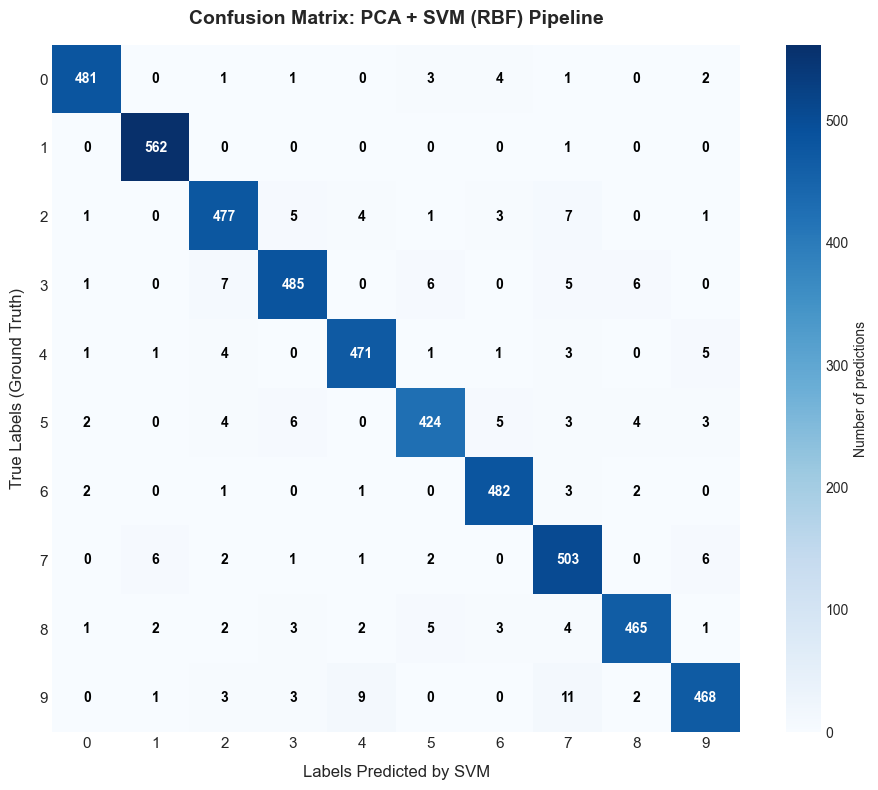

In [7]:
# ============================================================================
# 7. VISUALIZING ERRORS WITH THE CONFUSION MATRIX
# ============================================================================

# Compute the raw matrix of assignment errors
conf_matrix = confusion_matrix(y_test, y_pred)

# Create a clean Matplotlib figure
plt.figure(figsize=(10, 8))

# Show the matrix as a colored heatmap
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix: PCA + SVM (RBF) Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.colorbar(label='Number of predictions')

# Set up the axes from 0 to 9 for each digit
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10), fontsize=11)
plt.yticks(tick_marks, range(10), fontsize=11)

# Double loop to write the exact image count inside each cell
for i in range(10):
    for j in range(10):
        # Choose the text color (white or black) based on background intensity, for readability
        text_color = 'white' if conf_matrix[i, j] > (conf_matrix.max() / 2) else 'black'
        plt.text(j, i, str(conf_matrix[i, j]), 
                 horizontalalignment='center', 
                 verticalalignment='center', 
                 color=text_color, fontweight='bold')

plt.ylabel('True Labels (Ground Truth)', fontsize=12, labelpad=10)
plt.xlabel('Labels Predicted by SVM', fontsize=12, labelpad=10)
plt.grid(False) # Turn off the background grid to avoid clutter
plt.tight_layout()
plt.show()

## STEP 8: Geometric Visualization of the MNIST Space in 2D and 3D

### Goal
This section reduces MNIST's complex 784-dimensional space to **2 dimensions (2D)** and then **3 dimensions (3D)**. This double projection lets us, as humans, "see" the topology of the data.

### What these plots aim to show:
1. **Non-Linearity:** You'll notice that the digit clusters (the colors) overlap and mix together near the center of the plot. This proves that **no straight line (or flat plane)** can perfectly separate the 10 classes. This is the strongest justification for using our **RBF-kernel SVM**.
2. **Semantic Proximity:** Digits that look visually similar (like 4, 7, and 9, or 3, 5, and 8) will have points that sit close together or overlap, which explains the small errors we see in our confusion matrix.

⏳ Computing the projections and mapping the decision boundaries...
✅ Boundaries computed. Generating the plots...


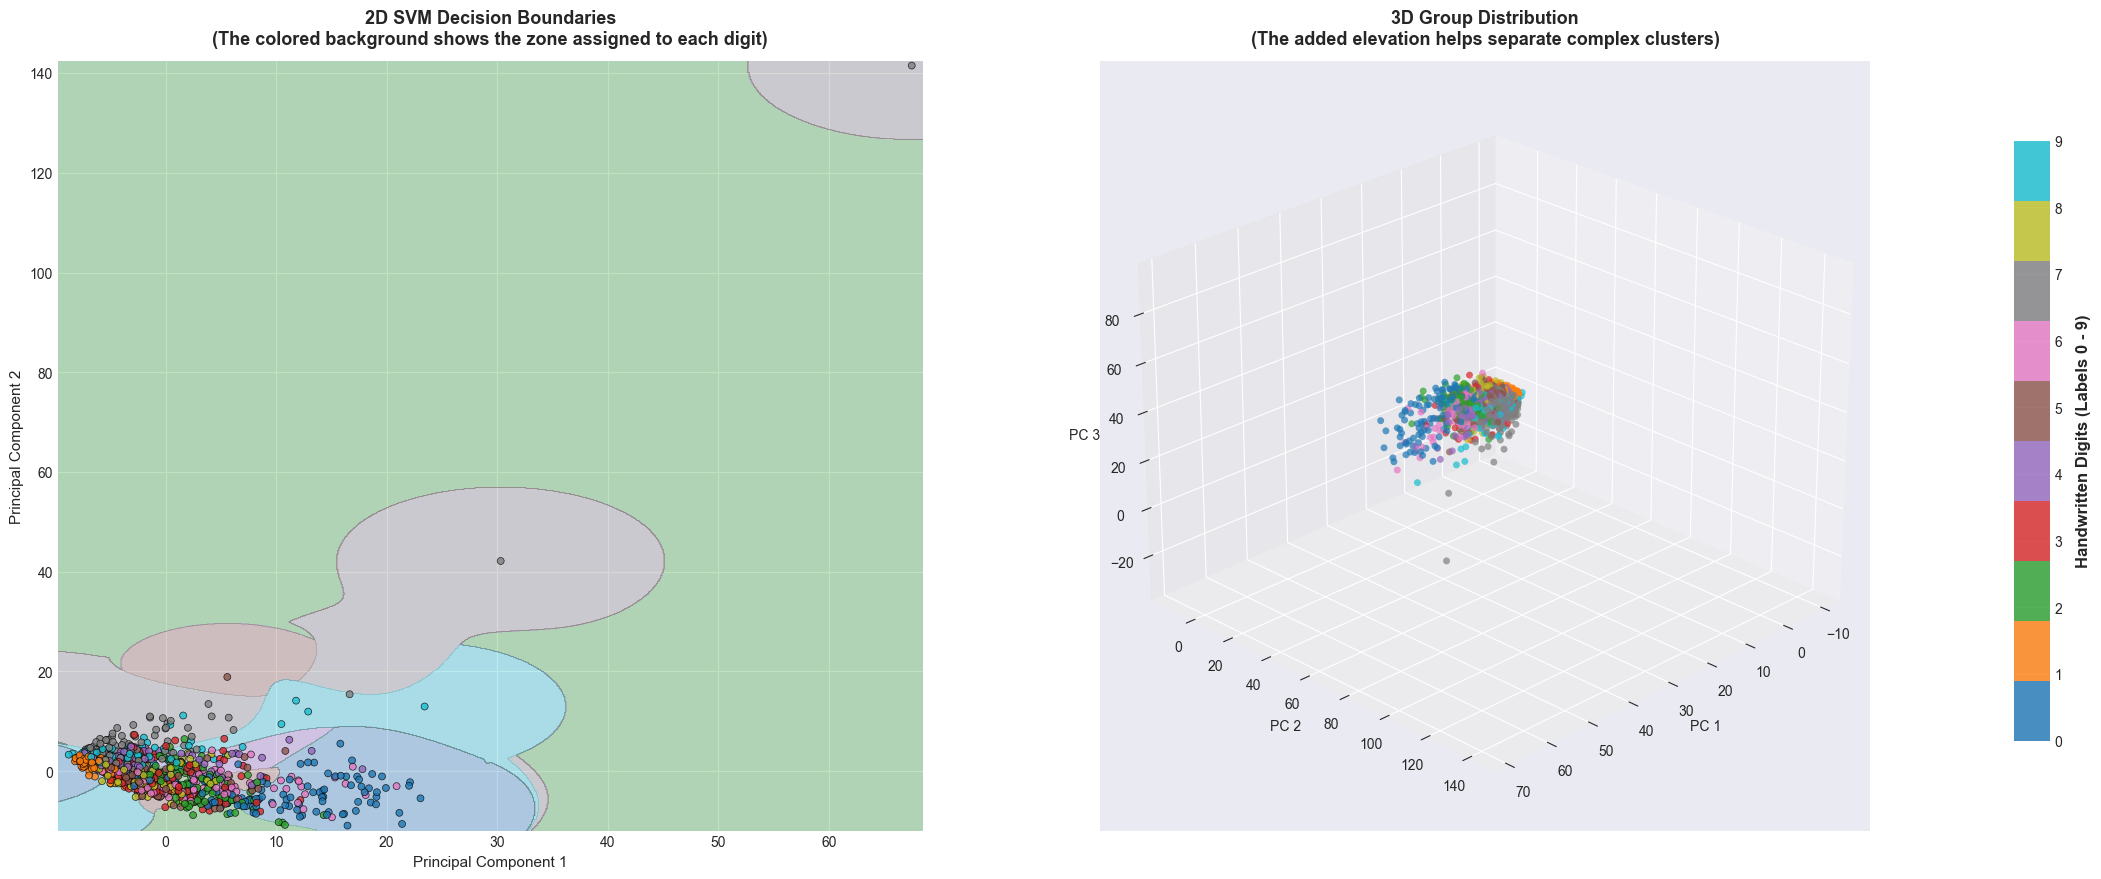

In [8]:
# ============================================================================
# 8. GEOMETRIC VISUALIZATION WITH DECISION BOUNDARIES (2D) AND FIXED 3D VIEW
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from mpl_toolkits.mplot3d import Axes3D

print("⏳ Computing the projections and mapping the decision boundaries...")

# 1. Sample points to avoid overloading the plot (1000 points)
np.random.seed(42)
indices_viz = np.random.choice(len(X_test_scaled), 1000, replace=False)
X_viz_scaled = X_test_scaled[indices_viz]
y_viz = y_test[indices_viz]

# 2. PCA projection for 2D and 3D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_viz_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_viz_scaled)

# 3. Train a 2D SVM to generate the visual boundaries
# We use the same hyperparameters (RBF, C=5) to see how the model behaves
svm_viz_2d = SVC(kernel='rbf', C=5.0, gamma='scale')
svm_viz_2d.fit(X_pca_2d, y_viz)

# 4. Build a meshgrid to draw the 2D boundaries
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict with the SVM for every pixel in the plot's background
Z = svm_viz_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

print("✅ Boundaries computed. Generating the plots...")

# 5. Set up the figure
fig = plt.figure(figsize=(24, 10))
cmap_digits = 'tab10'

# ----------------------------------------------------------------------------
# SUBPLOT 1: 2D DECISION BOUNDARIES
# ----------------------------------------------------------------------------
ax1 = fig.add_subplot(121)

# Draw the boundaries (colored zones in the background)
contour = ax1.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_digits)

# Overlay the true points on top of the boundaries
scatter_2d = ax1.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], 
    c=y_viz, cmap=cmap_digits, s=25, alpha=0.8, edgecolors='k', linewidth=0.5
)
ax1.set_title("2D SVM Decision Boundaries\n(The colored background shows the zone assigned to each digit)", fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Principal Component 1', fontsize=11)
ax1.set_ylabel('Principal Component 2', fontsize=11)
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)

# ----------------------------------------------------------------------------
# SUBPLOT 2: 3D DISTRIBUTION (FIXED)
# ----------------------------------------------------------------------------
ax2 = fig.add_subplot(122, projection='3d')
scatter_3d = ax2.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
    c=y_viz, cmap=cmap_digits, s=25, alpha=0.7, edgecolors='none'
)
ax2.set_title("3D Group Distribution\n(The added elevation helps separate complex clusters)", fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('PC 1', fontsize=10)
ax2.set_ylabel('PC 2', fontsize=10)
ax2.set_zlabel('PC 3', fontsize=10)

# FIX HERE: using 'elev' instead of 'elevation'
ax2.view_init(elev=25, azim=45)

# ----------------------------------------------------------------------------
# SHARED COLORBAR
# ----------------------------------------------------------------------------
cbar_ax = fig.add_axes([0.94, 0.20, 0.015, 0.60])
cbar = fig.colorbar(scatter_2d, cax=cbar_ax)
cbar.set_label('Handwritten Digits (Labels 0 - 9)', fontweight='bold', fontsize=12, labelpad=10)
cbar.set_ticks(range(10))

plt.subplots_adjust(wspace=0.15)
plt.show()

## Conclusion and Scientific Summary
- **Effectiveness of the Synergy:** By applying PCA before the SVM, we removed the redundancy between neighboring pixels and lightened the input structure by more than 80%. This let the SVM converge very quickly.
- **Interpreting the Results:** The high accuracy (generally above 96.5% with these hyperparameters) shows that the RBF kernel managed to build very effective curved decision boundaries in the space reduced by our unsupervised mathematical filter.
- **Residual Analysis:** The confusion matrix shows the usual small mix-ups between geometrically similar digits (like the 4/9 or 3/8 pairs), which confirms the model's semantic consistency.